In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('dataset_gizi_per_orang (dummy).csv')

# Inspect the data
print(df.head())
print(df.info())
print(f"Total unique children: {df['id_anak'].nunique()}")

  id_anak  usia_bulan jenis_kelamin  berat_badan_kg  tinggi_badan_cm    bmi  \
0    A001          21             L            9.18             75.9  15.94   
1    A001          24             L            9.73             76.9  16.45   
2    A001          27             L           11.05             76.7  18.78   
3    A001          30             L           10.95             78.1  17.96   
4    A001          33             L            9.84             79.8  15.43   

   zscore  
0    0.38  
1    0.57  
2    2.30  
3    1.46  
4    0.08  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_anak          480 non-null    object 
 1   usia_bulan       480 non-null    int64  
 2   jenis_kelamin    480 non-null    object 
 3   berat_badan_kg   480 non-null    float64
 4   tinggi_badan_cm  480 non-null    float64
 5   bmi              480 n

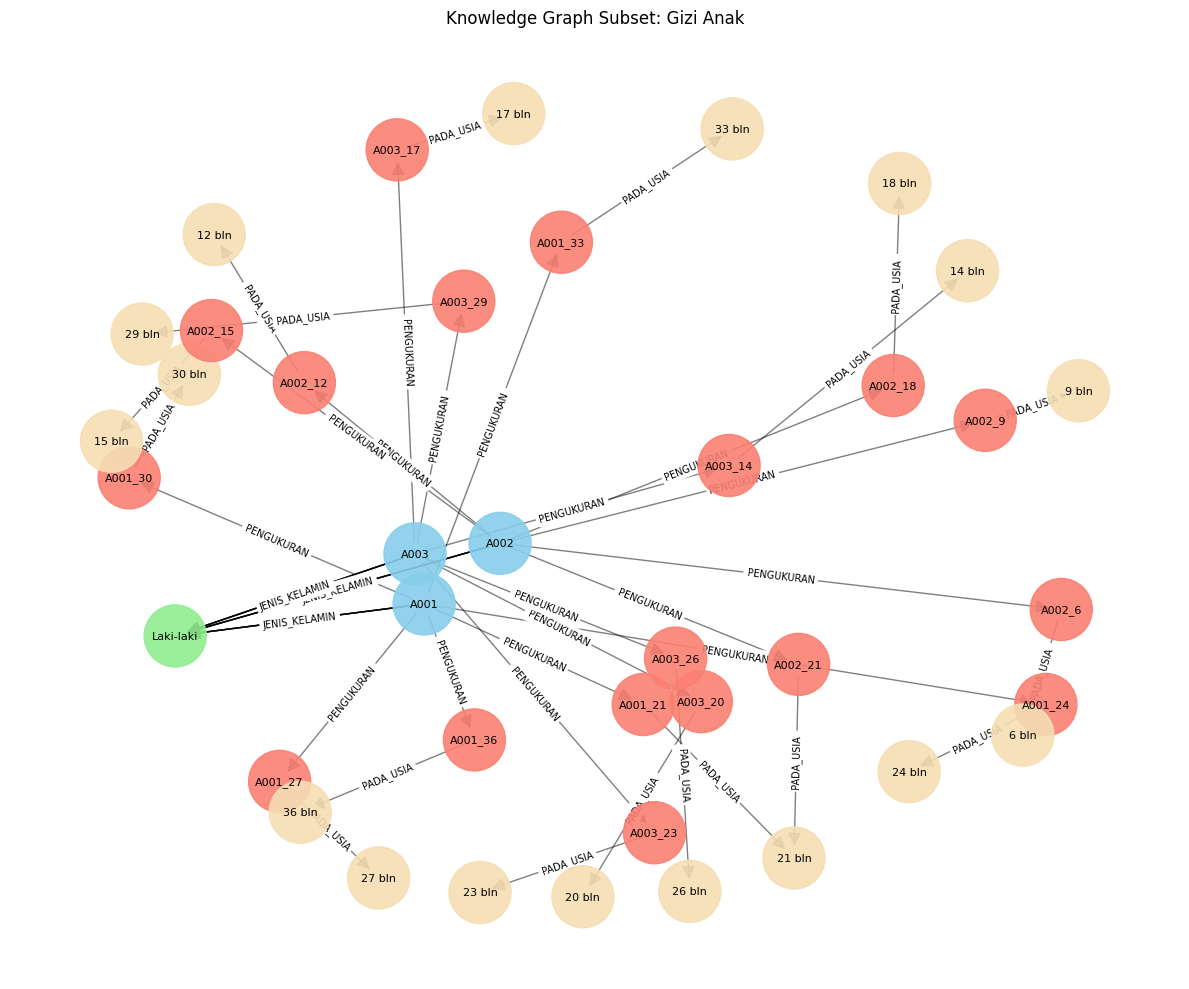

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Select a subset of children for visualization (e.g., first 3 children)
subset_ids = df['id_anak'].unique()[:3]
subset_df = df[df['id_anak'].isin(subset_ids)]

G = nx.MultiDiGraph()

# Define labels for genders
gender_map = {'L': 'Laki-laki', 'P': 'Perempuan'}

# Add nodes and edges
for _, row in subset_df.iterrows():
    child_id = row['id_anak']
    gender = gender_map.get(row['jenis_kelamin'], row['jenis_kelamin'])
    age = f"{row['usia_bulan']} bln"
    meas_id = f"{child_id}_{row['usia_bulan']}"
    
    # Nodes
    G.add_node(child_id, label='Anak', color='skyblue')
    G.add_node(gender, label='Jenis Kelamin', color='lightgreen')
    G.add_node(meas_id, label='Pengukuran', color='salmon')
    
    # Edges
    G.add_edge(child_id, gender, relation='JENIS_KELAMIN')
    G.add_edge(child_id, meas_id, relation='PENGUKURAN')
    
    # Attributes for measurement node (visualized as edge or label)
    # Adding age as a node connected to measurement
    G.add_node(age, label='Usia', color='wheat')
    G.add_edge(meas_id, age, relation='PADA_USIA')

# Visualization
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Draw nodes
node_colors = [G.nodes[n].get('color', 'grey') for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

# Draw edges
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, arrowsize=20)
edge_labels = {(u, v): d['relation'] for u, v, d in G.edges(data=True)}
# To avoid overlapping edge labels in MultiDiGraph, we just show unique pairs
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): edge_labels[(u,v)] for u,v in G.edges()}, font_size=7)

plt.title("Knowledge Graph Subset: Gizi Anak")
plt.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph_gizi.png')

# Also create a small table of triples for the user
triples = []
for u, v, d in G.edges(data=True):
    triples.append({'Subject': u, 'Predicate': d['relation'], 'Object': v})

triples_df = pd.DataFrame(triples).drop_duplicates()
triples_df.to_csv('knowledge_graph_triples.csv', index=False)

Graph saved as knowledge_graph_clear.png


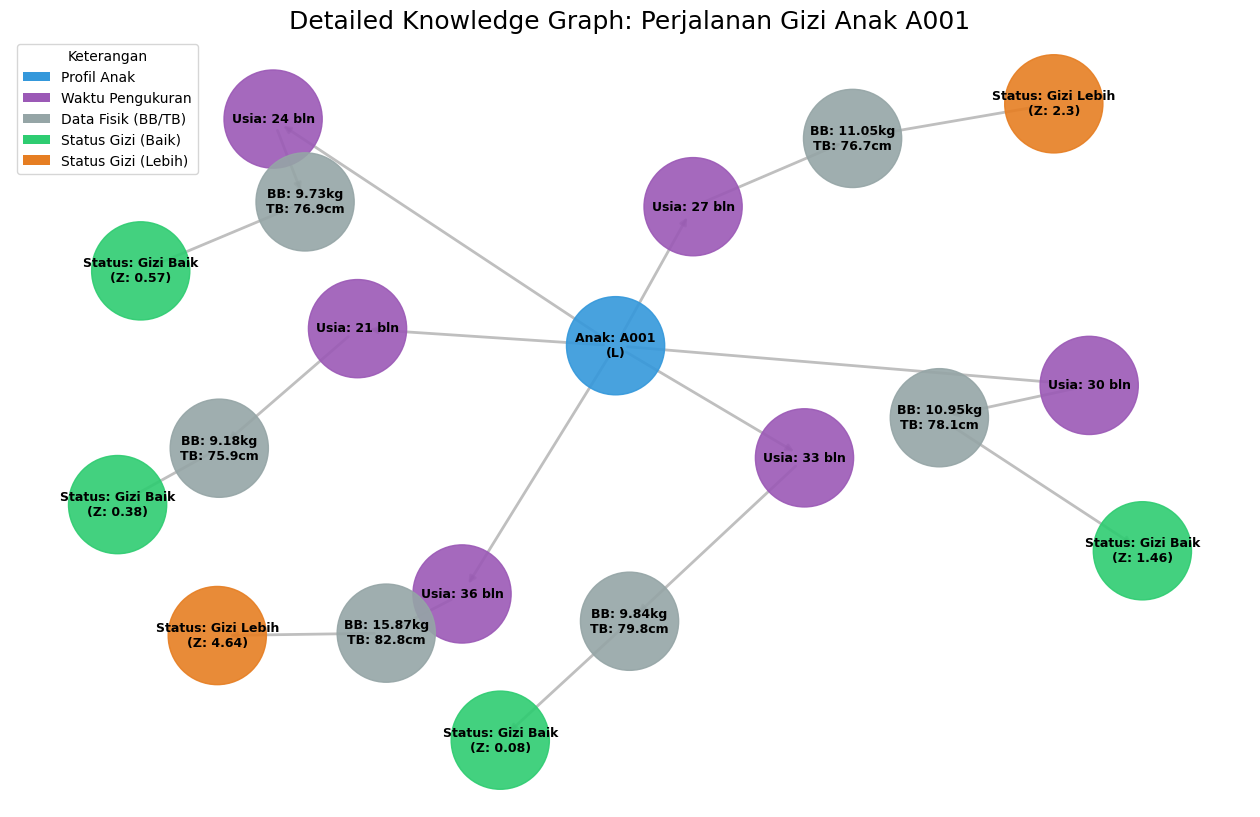

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('dataset_gizi_per_orang (dummy).csv')

# Categorize status
def get_status(z):
    if z < -3: return "Gizi Buruk"
    elif -3 <= z < -2: return "Gizi Kurang"
    elif -2 <= z <= 2: return "Gizi Baik"
    else: return "Gizi Lebih"

df['status'] = df['zscore'].apply(get_status)

# Focus on 1 child for maximum clarity
child_id = 'A001'
subset_df = df[df['id_anak'] == child_id]

G = nx.DiGraph()

# Central node
root_node = f"Anak: {child_id}\n({subset_df['jenis_kelamin'].iloc[0]})"
G.add_node(root_node, type='Main', color='#3498db')

# Colors for statuses
status_colors = {
    "Gizi Baik": "#2ecc71",
    "Gizi Lebih": "#e67e22",
    "Gizi Kurang": "#f1c40f",
    "Gizi Buruk": "#e74c3c"
}

for _, row in subset_df.iterrows():
    age_node = f"Usia: {row['usia_bulan']} bln"
    status_node = f"Status: {row['status']}\n(Z: {row['zscore']})"
    measure_node = f"BB: {row['berat_badan_kg']}kg\nTB: {row['tinggi_badan_cm']}cm"
    
    G.add_node(age_node, type='Age', color='#9b59b6')
    G.add_node(status_node, type='Status', color=status_colors.get(row['status'], 'gray'))
    G.add_node(measure_node, type='Measure', color='#95a5a6')
    
    G.add_edge(root_node, age_node)
    G.add_edge(age_node, measure_node)
    G.add_edge(measure_node, status_node)

# Layout
plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Colors and sizes
node_colors = [G.nodes[n]['color'] for n in G.nodes()]

# Draw
nx.draw_networkx_nodes(G, pos, node_size=5000, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray', arrows=True)
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold')

plt.title(f"Detailed Knowledge Graph: Perjalanan Gizi Anak {child_id}", fontsize=18)
plt.axis('off')

# Simple Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Profil Anak'),
    Patch(facecolor='#9b59b6', label='Waktu Pengukuran'),
    Patch(facecolor='#95a5a6', label='Data Fisik (BB/TB)'),
    Patch(facecolor='#2ecc71', label='Status Gizi (Baik)'),
    Patch(facecolor='#e67e22', label='Status Gizi (Lebih)')
]
plt.legend(handles=legend_elements, loc='best', title="Keterangan")

plt.savefig('knowledge_graph_clear.png', dpi=300, bbox_inches='tight')
print("Graph saved as knowledge_graph_clear.png")

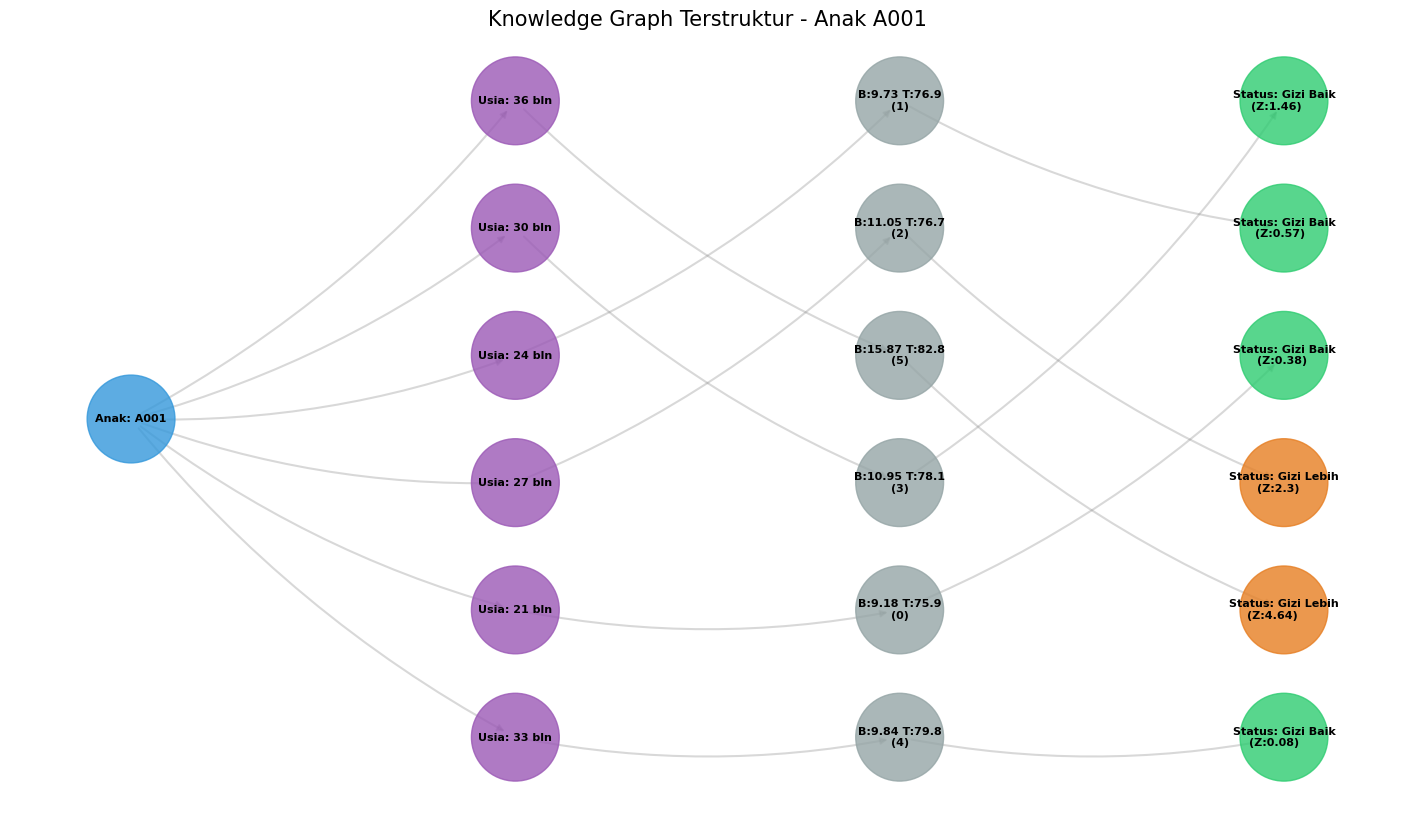

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('dataset_gizi_per_orang (dummy).csv')

def get_status(z):
    if z < -3: return "Gizi Buruk"
    elif -3 <= z < -2: return "Gizi Kurang"
    elif -2 <= z <= 2: return "Gizi Baik"
    else: return "Gizi Lebih"

df['status'] = df['zscore'].apply(get_status)

# Ambil subset agar tidak terlalu padat
child_id = 'A001'
subset_df = df[df['id_anak'] == child_id]

G = nx.DiGraph()

# Mapping status ke warna
status_colors = {"Gizi Baik": "#2ecc71", "Gizi Lebih": "#e67e22", "Gizi Kurang": "#f1c40f", "Gizi Buruk": "#e74c3c"}

# Bangun Graph dengan Layer untuk Multipartite
root_node = f"Anak: {child_id}"
G.add_node(root_node, layer=0, color='#3498db')

for i, row in subset_df.iterrows():
    age_node = f"Usia: {row['usia_bulan']} bln"
    measure_node = f"B:{row['berat_badan_kg']} T:{row['tinggi_badan_cm']}\n({i})" # Unique ID agar tidak tumpuk
    status_node = f"Status: {row['status']}\n(Z:{row['zscore']}) " + " "*i # Spasi unik
    
    G.add_node(age_node, layer=1, color='#9b59b6')
    G.add_node(measure_node, layer=2, color='#95a5a6')
    G.add_node(status_node, layer=3, color=status_colors.get(row['status'], 'gray'))
    
    G.add_edge(root_node, age_node)
    G.add_edge(age_node, measure_node)
    G.add_edge(measure_node, status_node)

# Gunakan Multipartite Layout agar node berbaris rapi per kategori
pos = nx.multipartite_layout(G, subset_key='layer')

plt.figure(figsize=(18, 10))
node_colors = [G.nodes[n]['color'] for n in G.nodes()]

# Gambar
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.3, edge_color='gray', arrows=True, connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif', font_weight='bold')

plt.title(f"Knowledge Graph Terstruktur - Anak {child_id}", fontsize=15)
plt.axis('off')
plt.savefig('knowledge_graph_clean_v3.png', dpi=300, bbox_inches='tight')